In [1]:
#Article ENERGIES
#Machine Learning with Administrative Data for Energy Poverty Identification in the UK
#Lin Zheng andEoghanMcKenna*
#UCLEnergy Institute, University College London, 14 Upper Woburn Place, London WC1H 0NN, UK;

In [2]:
#https://github.com/linzzuk/Energy_Poverty_Prediction_paper_EHS_data 
#REPLICATION CODE

In [3]:
# README - Dependencies
#Make sure to install the required Python packages before running the code

In [4]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
#ENERGY PREDICTION MODEL
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix,matthews_corrcoef,make_scorer,precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold,learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

from imblearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_selector as selector
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder


from imblearn.pipeline import make_pipeline as make_pipeline_with_sampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import BalancedBaggingClassifier

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import balanced_accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
import time

import time
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import cross_validate
from imblearn.pipeline import make_pipeline as make_pipeline_with_sampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.compose import make_column_selector as selector
from sklearn.model_selection import StratifiedKFold

In [6]:
df_ep_model = pd.read_csv('clean_data.csv')

In [7]:
# Initial error so checking where folder is - added by David Austin

import os
os.getcwd()

'C:\\Users\\davea'

In [8]:
# --- SPLIT / RECODE VARIABLES BEFORE SELECTING COLUMNS ---

# Recode hhltsick: 1 = disability, 2 = no disability → convert to 1/0
df_ep_model['hhltsick_flag'] = df_ep_model['hhltsick'].replace({1: 1, 2: 0})


In [9]:
df_ep_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10572 entries, 0 to 10571
Columns: 184 entries, fpLILEEflg to hhltsick_flag
dtypes: float64(19), int64(165)
memory usage: 14.8 MB


In [10]:
df_ep_model.columns

Index(['fpLILEEflg', 'AHCIncomeEQ_LILEE', 'fpfullinc', 'fuelexpn',
       'FuelCosteqFactor', 'EqAHCincDeciles_LILEE', 'elecmop', 'gasmop',
       'aagph2021_x', 'FPGAP_LILEE',
       ...
       'sap412', 'rdsap09', 'EPceeb12e', 'EPceir12e', 'EPceib12e',
       'Equivalised fuel costs', 'Equivalised AHC income',
       'household_income_threshold', 'fpLIHCflg', 'hhltsick_flag'],
      dtype='object', length=184)

In [11]:
# --- SPLIT / RECODE VARIABLES BEFORE SELECTING COLUMNS ---

# Recode hhltsick: 1 = disability, 2 = no disability → convert to 1/0
df_ep_model['hhltsick_flag'] = df_ep_model['hhltsick'].replace({1: 1, 2: 0})

# ----------------------------------------------------------


# COMBINATION OF INPUTS

# select variables for the model
list_census_proxy = [
    'hhsizex','sft','nssech9','nssecp9','hhtype11','ager',
    'sexhrp','hhcomp1','ndepchild','hhltsick_flag',   # <-- updated here
    'tenure2','prevten','tenex','tenure4x',
    'bedrqx','DWtype','fuelx'
]

list_other_inputs_proxy = ['HYEARGRx','FloorArea','housex']

list_NEED_proxy = ['sap12']

# Combination 1: Census only as inputs
# Combination 2: Census + other inputs
# Combination 3: Census + other inputs + NEED (SAP)

# get entire tidy dataset
df_ep_model = df_ep_model[
    list_census_proxy +
    list_other_inputs_proxy +
    list_NEED_proxy +
    ['fpLIHCflg']
]

df_ep_model.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10572 entries, 0 to 10571
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hhsizex        10572 non-null  int64  
 1   sft            10572 non-null  int64  
 2   nssech9        10572 non-null  int64  
 3   nssecp9        10572 non-null  int64  
 4   hhtype11       10572 non-null  int64  
 5   ager           10572 non-null  int64  
 6   sexhrp         10572 non-null  int64  
 7   hhcomp1        10572 non-null  int64  
 8   ndepchild      10572 non-null  int64  
 9   hhltsick_flag  10572 non-null  int64  
 10  tenure2        10572 non-null  int64  
 11  prevten        10572 non-null  int64  
 12  tenex          10572 non-null  int64  
 13  tenure4x       10572 non-null  int64  
 14  bedrqx         10572 non-null  int64  
 15  DWtype         10572 non-null  int64  
 16  fuelx          10572 non-null  int64  
 17  HYEARGRx       10572 non-null  float64
 18  FloorA

In [12]:
# DATA SPLIT
# copy dataframe (entire tidy dataset is all inputs + target data for data split in train set and test set, test set will be used for final evaluation)
X = df_ep_model.drop(columns=['fpLIHCflg']).copy()
y = df_ep_model['fpLIHCflg'].copy()

# data split
Train_x, Test_x, Train_y, Test_y = train_test_split(X, y, stratify=y, random_state=42)
Train_x.shape, Test_x.shape, Train_y.shape, Test_y.shape

# we separate the test set and only use it for the final evaluation

((7929, 21), (2643, 21), (7929,), (2643,))

In [13]:
#FUNCTIONS
# Model section and handling imbalance data in classification
# Define a fixed Stratified K-Fold object (to make sure that the same folds are used for both model selection and hyperparameter tuning)
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
def select_models(X, y):

    start = time.time()

    scoring = ["accuracy", "balanced_accuracy"]

    # Preprocessor for Random Forest
    num_pipe_rf = make_pipeline(
        SimpleImputer(strategy="mean", add_indicator=True),
        StandardScaler()
    )

    cat_pipe_rf = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="missing"),
        OneHotEncoder(handle_unknown="ignore")
    )

    preprocessor_rf = make_column_transformer(
        (num_pipe_rf, selector(dtype_include="number")),
        (cat_pipe_rf, selector(dtype_include="category")),
        n_jobs=-1
    )

    # Preprocessor for XGBoost + Logistic Regression
    num_pipe_xgb = make_pipeline(
        SimpleImputer(strategy="mean", add_indicator=True),
        StandardScaler()
    )

    cat_pipe_xgb = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="missing"),
        OneHotEncoder(handle_unknown="ignore")
    )

    preprocessor_xgb = make_column_transformer(
        (num_pipe_xgb, selector(dtype_include="number")),
        (cat_pipe_xgb, selector(dtype_include="category")),
        n_jobs=-1
    )

    index = []
    scores = {"Accuracy": [], "Balanced accuracy": []}

    # Dummy classifier
    dummy_clf = DummyClassifier(strategy="most_frequent")
    index.append("Dummy classifier")
    cv_result = cross_validate(dummy_clf, X, y, scoring=scoring, cv=cv_folds)
    scores["Accuracy"].append(cv_result["test_accuracy"].mean())
    scores["Balanced accuracy"].append(cv_result["test_balanced_accuracy"].mean())

    # Logistic Regression
    log_reg_clf = make_pipeline(
        preprocessor_xgb,
        LogisticRegression(class_weight="balanced", max_iter=1000)
    )
    index.append("Logistic Regression (balanced)")
    cv_result = cross_validate(log_reg_clf, X, y, scoring=scoring, cv=cv_folds)
    scores["Accuracy"].append(cv_result["test_accuracy"].mean())
    scores["Balanced accuracy"].append(cv_result["test_balanced_accuracy"].mean())

    # Random Forest + undersampling
    rf_clf = make_pipeline_with_sampler(
        preprocessor_rf,
        RandomUnderSampler(random_state=42),
        RandomForestClassifier(random_state=42, n_jobs=-1)
    )
    index.append("Random forest with undersampling")
    cv_result = cross_validate(rf_clf, X, y, scoring=scoring, cv=cv_folds)
    scores["Accuracy"].append(cv_result["test_accuracy"].mean())
    scores["Balanced accuracy"].append(cv_result["test_balanced_accuracy"].mean())

    # Random Forest + class weights
    rf_clf.set_params(randomforestclassifier__class_weight="balanced")
    index.append("Random forest with balanced class weights")
    cv_result = cross_validate(rf_clf, X, y, scoring=scoring, cv=cv_folds)
    scores["Accuracy"].append(cv_result["test_accuracy"].mean())
    scores["Balanced accuracy"].append(cv_result["test_balanced_accuracy"].mean())

    # XGBoost + undersampling
    xgb_clf = make_pipeline_with_sampler(
        preprocessor_xgb,
        RandomUnderSampler(random_state=42),
        XGBClassifier(random_state=42, n_jobs=-1)
    )
    index.append("XGBoost with undersampling")
    cv_result = cross_validate(xgb_clf, X, y, scoring=scoring, cv=cv_folds)
    scores["Accuracy"].append(cv_result["test_accuracy"].mean())
    scores["Balanced accuracy"].append(cv_result["test_balanced_accuracy"].mean())

    # XGBoost + scale_pos_weight
    num_neg = (y == 0).sum()
    num_pos = (y == 1).sum()
    scale_pos_weight = num_neg / num_pos

    xgb_balanced = make_pipeline(
        preprocessor_xgb,
        XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            n_jobs=-1
        )
    )
    index.append("XGBoost with scale_pos_weight")
    cv_result = cross_validate(xgb_balanced, X, y, scoring=scoring, cv=cv_folds)
    scores["Accuracy"].append(cv_result["test_accuracy"].mean())
    scores["Balanced accuracy"].append(cv_result["test_balanced_accuracy"].mean())

    df_scores = pd.DataFrame(scores, index=index)
    df_scores.drop("Dummy classifier", inplace=True)

    end = time.time()
    print(f"Time elapsed: {end - start:.2f} s")

    return df_scores, xgb_balanced, preprocessor_xgb, scale_pos_weight


In [15]:
# Optimized function for xgb model hyperparameter tuning

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

def tune_xgboost(selected_model, preprocessor_xgb, scale_pos_weight, X_train, y_train, n_iter=30):
    """
    Tunes hyperparameters for the selected XGBoost model with preprocessing inside a pipeline.

    Parameters:
    - selected_model: The model chosen from model selection (Pipeline with XGBoost)
    - preprocessor_xgb: The preprocessor for XGBoost (ColumnTransformer)
    - scale_pos_weight: The computed class imbalance ratio from model selection
    - X_train: Training features
    - y_train: Training labels
    - n_iter: Number of hyperparameter combinations to test (default=30)

    Returns:
    - best_model: The best hyperparameter-tuned XGBoost model (Pipeline)
    - best_params: Best hyperparameters found
    """

    print("Hyperparameter tuning with RandomizedSearchCV")

    # Extract preprocessing step from the selected pipeline
    preprocessor = preprocessor_xgb # Ensure this matches pipeline step name

    # Rebuild the model with scale_pos_weight fixed
    xgb_tune = XGBClassifier(
        scale_pos_weight=scale_pos_weight,  # Ensure it is retained!
        random_state=42,
        n_jobs=-1
    )

    # Define full pipeline (preprocessing + model)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Include preprocessing step
        ('xgb', xgb_tune)  # XGBoost model
    ])

    # Define hyperparameter search space (corrected with "xgb__" prefix)
    param_dist = {
        'xgb__n_estimators': randint(100, 500),
        'xgb__learning_rate': uniform(0.01, 0.3),
        'xgb__max_depth': randint(3, 12),
        'xgb__subsample': uniform(0.5, 0.5),
        'xgb__colsample_bytree': uniform(0.5, 0.5),
        'xgb__gamma': uniform(0, 5),
        'xgb__reg_lambda': uniform(0, 10),
        'xgb__reg_alpha': uniform(0, 10)
    }

    # Setup RandomizedSearchCV (using the same CV folds as model selection)
    random_search = RandomizedSearchCV(
        estimator=pipeline,  # Tune the entire pipeline (preprocessor + XGBoost)
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv_folds,  # Ensure same cross-validation folds as model selection
        scoring='balanced_accuracy',
        n_jobs=-1,
        random_state=42
    )

    # Fit RandomizedSearchCV
    random_search.fit(X_train, y_train)

    # Extract best pipeline (preprocessing + tuned XGB)
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_score = random_search.best_score_

    # Print results
    print("\nHyperparameter Tuning Complete")
    print("Best Hyperparameters:", best_params)
    print(f"Best Balanced Accuracy: {best_score:.4f}")

    return best_model, best_params

In [16]:
# Set custom threshold for confusion matrix

def tune_classification_threshold(best_model, X_test, y_test, set_threshold=0.5, risk_label=1):
    """
    Tunes classification threshold and evaluates model performance.

    Parameters:
    - best_model: Trained classifier with `predict_proba()`
    - X_test: pd.DataFrame - Test set features
    - y_test: pd.Series - True labels for test set
    - set_threshold: float - The threshold to use for final evaluation (default=0.5)
    - risk_label: int - The class label for "at risk" classification (default=1)

    Returns:
    - best_threshold: float - Optimal threshold for highest F1 score
    - metrics_at_custom_threshold: dict - Evaluation metrics at custom threshold
    """

    print("Tuning classification threshold")

    # Get probabilities for each class
    probs = best_model.predict_proba(X_test)

    # Define threshold values
    thresholds = np.linspace(0, 1, 101)  # Generate 101 thresholds from 0 to 1

    # Initialize lists to store metrics
    f1_scores = []
    precisions = []
    recalls = []
    specificities = []
    accuracies = []

    # Loop through each threshold and compute metrics
    for threshold in thresholds:
        preds = (probs[:, risk_label] >= threshold).astype(int)
        
        # Compute confusion matrix components
        tn, fp, fn, tp = confusion_matrix(y_test == risk_label, preds).ravel()
        
        # Compute metrics safely (avoid division by zero)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = accuracy_score(y_test == risk_label, preds)

        # Store results
        f1_scores.append(f1)
        precisions.append(precision)
        recalls.append(recall)
        specificities.append(specificity)
        accuracies.append(accuracy)

    # Find the best threshold (based on F1-score)
    best_f1 = max(f1_scores)
    best_threshold = thresholds[f1_scores.index(best_f1)]
    print(f"\n🔹 Best threshold for highest F1-score: {best_threshold:.2f}")

    # Define the custom threshold
    custom_threshold = set_threshold

    # Evaluate model at the custom threshold
    best_preds = (probs[:, risk_label] >= custom_threshold).astype(int)
    cm = confusion_matrix(y_test == risk_label, best_preds)

    # Plot all metrics against threshold
    plt.figure(figsize=(10, 8))
    plt.plot(thresholds, f1_scores, label="F1 Score", marker='.')
    plt.plot(thresholds, precisions, label="Precision", marker='.')
    plt.plot(thresholds, recalls, label="Recall", marker='.')
    plt.plot(thresholds, specificities, label="Specificity", marker='.')
    plt.plot(thresholds, accuracies, label="Accuracy", marker='.')
    plt.axvline(custom_threshold, color='black', linestyle='--', label=f"Custom Threshold ({custom_threshold:.2f})")
    # plt.axvline(best_threshold, color='g', linestyle='--', label=f"Best F1 Threshold ({best_threshold:.2f})")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Model Metrics vs. Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Classification report at the selected custom threshold
    print(f"\n🔹 Classification report at custom threshold ({custom_threshold:.2f}):")
    print(classification_report(y_test == risk_label, best_preds, target_names=['Not at risk', 'At risk']))
    
    # Compute balanced accuracy
    bal_acc = balanced_accuracy_score(y_test == risk_label, best_preds)
    print(f"🔹 Balanced Accuracy at threshold {custom_threshold:.2f}: {bal_acc:.4f}")

    # Store results in a dictionary
    metrics_at_custom_threshold = {
        "Custom Threshold": custom_threshold,
        "Best F1 Threshold": best_threshold,
        "Balanced Accuracy": bal_acc,
        "F1 Score": f1_scores[thresholds.tolist().index(custom_threshold)],
        "Precision": precisions[thresholds.tolist().index(custom_threshold)],
        "Recall": recalls[thresholds.tolist().index(custom_threshold)],
        "Specificity": specificities[thresholds.tolist().index(custom_threshold)],
        "Accuracy": accuracies[thresholds.tolist().index(custom_threshold)],
        "Confusion Matrix": cm
    }

    return best_threshold, metrics_at_custom_threshold

In [17]:
# COM-1 : Census only model

# select inputs and target variable for COM-1, use only train set for model selection
df_res = Train_x[list_census_proxy].copy()
y_res = Train_y.copy()

# compare model selection results, get the best selected model (xgb), sgb_preprocessor and scale_pos_weight
df_scores, select_model,preprocessor_xgb,scale_pos_weight = select_models(df_res, y_res)
df_scores

Time elapsed: 27.41 s


,Accuracy,Balanced accuracy
Logistic Regression (balanced),0.794426,0.771572
Random forest with undersampling,0.778284,0.778742
Random forest with balanced class weights,0.778284,0.778742
XGBoost with undersampling,0.778030,0.777398
XGBoost with scale_pos_weight,0.829741,0.784160


In [18]:
# XGBoost Model training, tunning parameters, evaluation

# copy data, make sure that train set is the same to data used for model selection, and test set is the one we separated at the beginning
X_train = df_res.copy()
y_train = y_res.copy()

X_test = Test_x[list_census_proxy].copy()
y_test = Test_y.copy()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7929, 17), (2643, 17), (7929,), (2643,))

In [19]:
# Train the model by X_train and y_train, and optimize XGBoost model by tunning hyperparameters, get the best model
best_model, best_params = tune_xgboost(select_model,preprocessor_xgb, scale_pos_weight, X_train, y_train,)

# Best model performance
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

Hyperparameter tuning with RandomizedSearchCV

Hyperparameter Tuning Complete
Best Hyperparameters: {'xgb__colsample_bytree': 0.6210276357557503, 'xgb__gamma': 3.360677737029393, 'xgb__learning_rate': 0.23848588459861528, 'xgb__max_depth': 3, 'xgb__n_estimators': 354, 'xgb__reg_alpha': 8.031397563798958, 'xgb__reg_lambda': 4.703006344460384, 'xgb__subsample': 0.9917115704474215}
Best Balanced Accuracy: 0.8091
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      2285
           1       0.37      0.78      0.50       358

    accuracy                           0.79      2643
   macro avg       0.67      0.79      0.69      2643
weighted avg       0.88      0.79      0.82      2643

Balanced Accuracy: 0.7885193697052675


Tuning classification threshold

🔹 Best threshold for highest F1-score: 0.76


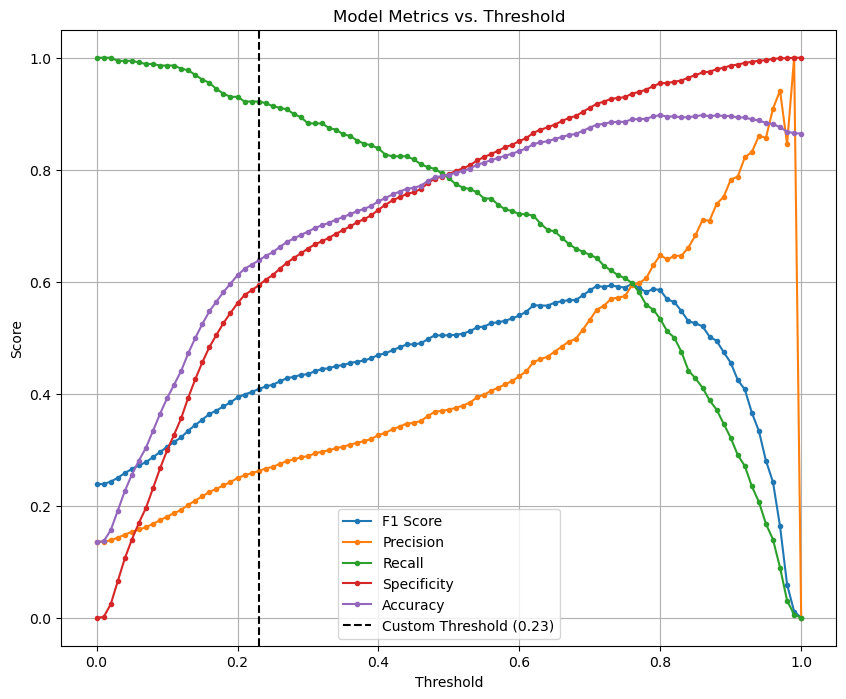


🔹 Classification report at custom threshold (0.23):
              precision    recall  f1-score   support

 Not at risk       0.98      0.59      0.74      2285
     At risk       0.26      0.92      0.41       358

    accuracy                           0.64      2643
   macro avg       0.62      0.76      0.57      2643
weighted avg       0.88      0.64      0.69      2643

🔹 Balanced Accuracy at threshold 0.23: 0.7576


In [20]:
# Custom setting threshold and get the best threshold for highest Recall
best_threshold, metrics_at_custom_threshold = tune_classification_threshold(best_model, X_test, y_test, set_threshold=0.23)

ROC AUC: 0.88


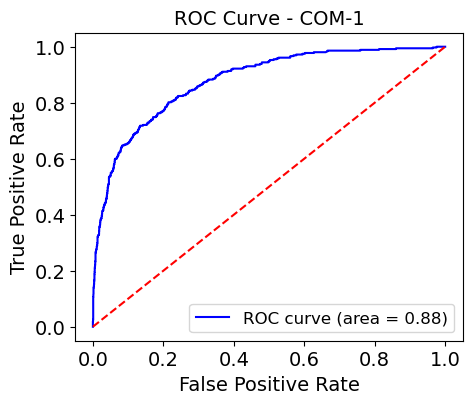

In [21]:
# Calculate ROC AUC score
#  "at risk" is class 1
double_risk_label = 1
# Get probabilities for each class
probs = best_model.predict_proba(X_test)

roc_auc = roc_auc_score(y_test, probs[:, double_risk_label])
print(f"ROC AUC: {roc_auc:.2f}")

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, probs[:, double_risk_label])

# Plot ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

# Adjust font sizes
plt.xlabel("False Positive Rate", fontsize=14)  
plt.ylabel("True Positive Rate", fontsize=14)  
plt.title("ROC Curve - COM-1", fontsize=14)  
plt.legend(fontsize=12)  
plt.xticks(fontsize=14)  
plt.yticks(fontsize=14)  

plt.savefig('./plots_of_results/roc_curve_com_1.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# COM-2 : Census + other inputs

# select inputs and target variable for COM-2, use only train set for model selection
df_res = Train_x[list_census_proxy + list_other_inputs_proxy].copy()
y_res = Train_y.copy()

# compare model selection results, get the best selected model (xgb), sgb_preprocessor and scale_pos_weight
df_scores, select_model,preprocessor_xgb,scale_pos_weight = select_models(df_res, y_res)
df_scores

Time elapsed: 6.13 s


,Accuracy,Balanced accuracy
Logistic Regression (balanced),0.858116,0.863771
Random forest with undersampling,0.862531,0.871831
Random forest with balanced class weights,0.862531,0.871831
XGBoost with undersampling,0.868457,0.874083
XGBoost with scale_pos_weight,0.899609,0.873645


In [23]:
# XGBoost Model training, tunning parameters, evaluation

# copy data, make sure that train set is the same to data used for model selection, and test set is the one we separated at the beginning
X_train = df_res.copy()
y_train = y_res.copy()

X_test = Test_x[list_census_proxy + list_other_inputs_proxy].copy()
y_test = Test_y.copy()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7929, 20), (2643, 20), (7929,), (2643,))

In [24]:
# Train the model by X_train and y_train, and optimize XGBoost model by tunning hyperparameters, get the best model
best_model, best_params = tune_xgboost(select_model,preprocessor_xgb, scale_pos_weight, X_train, y_train,)

# Best model performance
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

Hyperparameter tuning with RandomizedSearchCV

Hyperparameter Tuning Complete
Best Hyperparameters: {'xgb__colsample_bytree': 0.6872700594236812, 'xgb__gamma': 4.75357153204958, 'xgb__learning_rate': 0.22959818254342154, 'xgb__max_depth': 7, 'xgb__n_estimators': 202, 'xgb__reg_alpha': 4.458327528535912, 'xgb__reg_lambda': 0.9997491581800289, 'xgb__subsample': 0.7296244459829335}
Best Balanced Accuracy: 0.8891
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      2285
           1       0.53      0.87      0.66       358

    accuracy                           0.88      2643
   macro avg       0.75      0.87      0.79      2643
weighted avg       0.92      0.88      0.89      2643

Balanced Accuracy: 0.8730046575308974


Tuning classification threshold

🔹 Best threshold for highest F1-score: 0.66


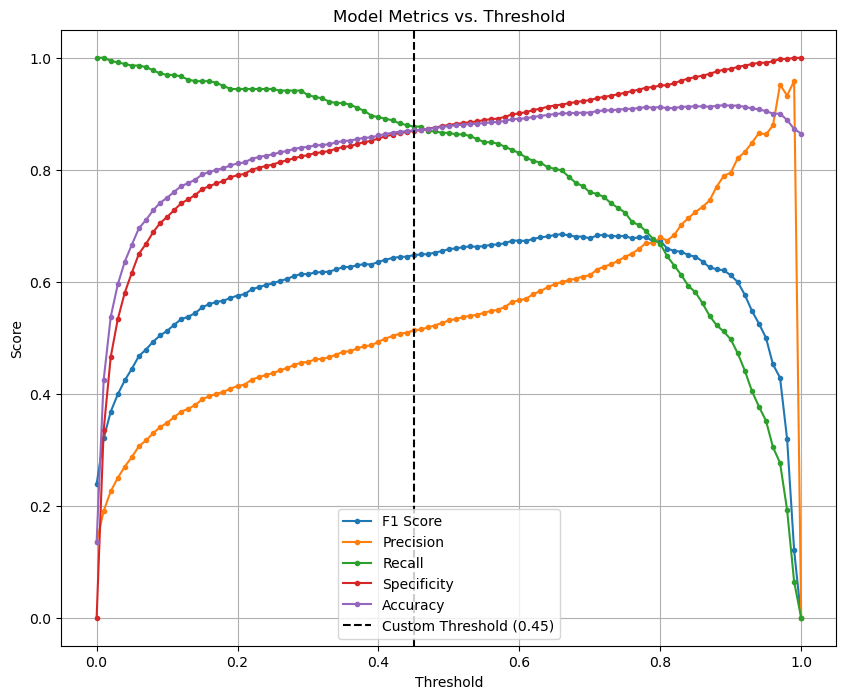


🔹 Classification report at custom threshold (0.45):
              precision    recall  f1-score   support

 Not at risk       0.98      0.87      0.92      2285
     At risk       0.51      0.88      0.65       358

    accuracy                           0.87      2643
   macro avg       0.75      0.87      0.78      2643
weighted avg       0.92      0.87      0.88      2643

🔹 Balanced Accuracy at threshold 0.45: 0.8733


In [25]:
# Custom setting threshold and get the best threshold for highest Recall
best_threshold, metrics_at_custom_threshold = tune_classification_threshold(best_model, X_test, y_test, set_threshold=0.45)

ROC AUC: 0.95


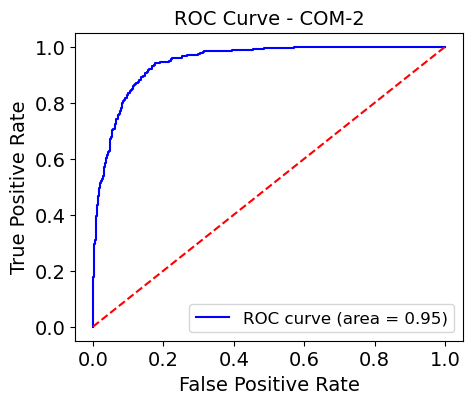

In [26]:
# Calculate ROC AUC score

#  "at risk" is class 1
double_risk_label = 1
# Get probabilities for each class
probs = best_model.predict_proba(X_test)

roc_auc = roc_auc_score(y_test, probs[:, double_risk_label])
print(f"ROC AUC: {roc_auc:.2f}")

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, probs[:, double_risk_label])

# Plot ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

# Adjust font sizes
plt.xlabel("False Positive Rate", fontsize=14)  
plt.ylabel("True Positive Rate", fontsize=14)  
plt.title("ROC Curve - COM-2", fontsize=14)  
plt.legend(fontsize=12)  
plt.xticks(fontsize=14)  
plt.yticks(fontsize=14)  

plt.savefig('./plots_of_results/roc_curve_com_2.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# copy data, make sure that train set is the same to data used for model selection, and test set is the one we separated at the beginning
X_train = df_res.copy()
y_train = y_res.copy()

X_test = Test_x[['HYEARGRx','sap12']].copy()
y_test = Test_y.copy()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7929, 20), (2643, 2), (7929,), (2643,))

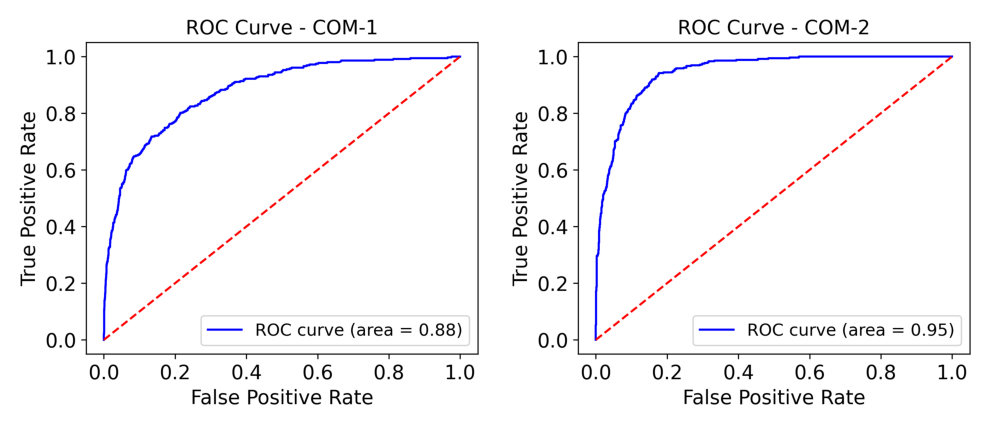

In [28]:
# Orgnise result plot

# organize the results plot in one figure, for roc_curve_com_1, roc_curve_com_2, roc_curve_com_3
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

# ROC curve for COM-1
path = './plots_of_results/roc_curve_com_1.png'
img = plt.imread(path)
axs[0].imshow(img)
axs[0].axis('off')

# ROC curve for COM-2
path = './plots_of_results/roc_curve_com_2.png'
img = plt.imread(path)
axs[1].imshow(img)
axs[1].axis('off')

plt.tight_layout()
plt.savefig('./plots_of_results/roc_curve_comparisons.png', dpi=300, bbox_inches='tight')
plt.show()

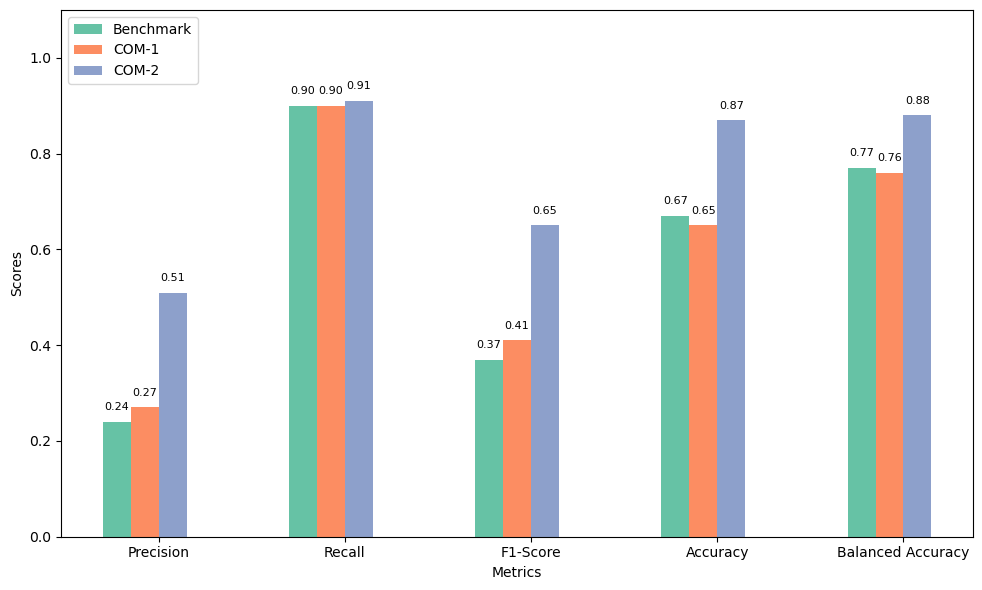

In [29]:
# Plotting Performance metric result
# plot performance metrics for all models
metric_results = pd.read_csv('performance_metric_result.csv')
metrics = ["Precision", "Recall", "F1-Score", "Accuracy", "Balanced Accuracy"]
bar_width = 0.15
index = np.arange(len(metrics))

# Extract performance scores
benchmark = metric_results.loc[0, metrics].values
com1 = metric_results.loc[1, metrics].values
com2 = metric_results.loc[2, metrics].values

# Define colors
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"] 
# Use Seaborn Set2 colors
set2_colors = sns.color_palette("Set2", 34)  # Extract 4 colors for the models

# Creating the bar plot
plt.figure(figsize=(10, 6))
bars = []

# Plot bars and store bar containers
bars.append(plt.bar(index, benchmark, bar_width, label="Benchmark", color=set2_colors[0], alpha=1))
bars.append(plt.bar(index + bar_width, com1, bar_width, label="COM-1", color=set2_colors[1], alpha=1))
bars.append(plt.bar(index + 2 * bar_width, com2, bar_width, label="COM-2", color=set2_colors[2], alpha=1))

# Adding value labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}",
                 ha='center', va='bottom', fontsize=8, color='black', rotation=0)

# Formatting the plot
plt.xlabel("Metrics")
plt.ylabel("Scores")
# plt.title("Performance Comparison Across Models")
plt.xticks(index + 1.5 * bar_width, metrics)
plt.legend(loc="upper left")
plt.ylim(0, 1.1)  # Adjust ylim to make space for labels

plt.tight_layout()
plt.savefig('./plots_of_results/model_performance_metrics_labeled.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# ============================================================
#   SIMPLE ACCURACY TABLE FOR DISABLED vs NOT DISABLED
# ============================================================

from sklearn.metrics import accuracy_score

# ---- fit the model on the SAME columns used in model selection ----
select_model.fit(Train_x[list_census_proxy], Train_y)

# ---- get predictions using the SAME columns ----
y_pred = select_model.predict(Test_x[list_census_proxy])

# ---- create masks ----
disabled_mask = (Test_x['hhltsick_flag'] == 1)
not_disabled_mask = (Test_x['hhltsick_flag'] == 0)

# ---- compute accuracies ----
acc_disabled = accuracy_score(Test_y[disabled_mask], y_pred[disabled_mask])
acc_not_disabled = accuracy_score(Test_y[not_disabled_mask], y_pred[not_disabled_mask])

# ---- build table ----
hhst_table = pd.DataFrame({
    'Group': ['Disabled (1)', 'Not Disabled (0)'],
    'Accuracy': [acc_disabled, acc_not_disabled]
})

hhst_table


,Group,Accuracy
0,Disabled (1),0.751825
1,Not Disabled (0),0.829457


In [31]:
# ============================================================
#   DETAILED ACCURACY TABLE FOR DISABLED vs NOT DISABLED
# ============================================================

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score
)

# ---- fit the model on the SAME columns used in model selection ----
select_model.fit(Train_x[list_census_proxy], Train_y)

# ---- get predictions using the SAME columns ----
y_pred = select_model.predict(Test_x[list_census_proxy])

# ---- create masks ----
disabled_mask = (Test_x['hhltsick_flag'] == 1)
not_disabled_mask = (Test_x['hhltsick_flag'] == 0)

# ---- function to compute detailed metrics ----
def metrics_for_group(mask):
    return {
        "Accuracy": accuracy_score(Test_y[mask], y_pred[mask]),
        "Balanced Accuracy": balanced_accuracy_score(Test_y[mask], y_pred[mask]),
        "Precision": precision_score(Test_y[mask], y_pred[mask]),
        "Recall": recall_score(Test_y[mask], y_pred[mask]),
        "F1 Score": f1_score(Test_y[mask], y_pred[mask])
    }

# ---- compute metrics ----
metrics_disabled = metrics_for_group(disabled_mask)
metrics_not_disabled = metrics_for_group(not_disabled_mask)

# ---- build table ----
hhst_table = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1 Score"],
    "Disabled (1)": [
        metrics_disabled["Accuracy"],
        metrics_disabled["Balanced Accuracy"],
        metrics_disabled["Precision"],
        metrics_disabled["Recall"],
        metrics_disabled["F1 Score"]
    ],
    "Not Disabled (0)": [
        metrics_not_disabled["Accuracy"],
        metrics_not_disabled["Balanced Accuracy"],
        metrics_not_disabled["Precision"],
        metrics_not_disabled["Recall"],
        metrics_not_disabled["F1 Score"]
    ]
})

hhst_table


,Metric,Disabled (1),Not Disabled (0)
0,Accuracy,0.751825,0.829457
1,Balanced Accuracy,0.798202,0.734688
2,Precision,0.404959,0.347561
3,Recall,0.869822,0.612903
4,F1 Score,0.552632,0.443580


In [32]:
# ============================================================
#   DETAILED ACCURACY TABLE + DATA SPLIT FOR DISABILITY GROUPS
# ============================================================

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score
)

# ---- fit the model on the SAME columns used in model selection ----
select_model.fit(Train_x[list_census_proxy], Train_y)

# ---- get predictions using the SAME columns ----
y_pred = select_model.predict(Test_x[list_census_proxy])

# ---- create masks ----
disabled_mask = (Test_x['hhltsick_flag'] == 1)
not_disabled_mask = (Test_x['hhltsick_flag'] == 0)

# ---- group sizes (data split) ----
n_disabled = disabled_mask.sum()
n_not_disabled = not_disabled_mask.sum()

# ---- function to compute detailed metrics ----
def metrics_for_group(mask):
    return {
        "Accuracy": accuracy_score(Test_y[mask], y_pred[mask]),
        "Balanced Accuracy": balanced_accuracy_score(Test_y[mask], y_pred[mask]),
        "Precision": precision_score(Test_y[mask], y_pred[mask]),
        "Recall": recall_score(Test_y[mask], y_pred[mask]),
        "F1 Score": f1_score(Test_y[mask], y_pred[mask])
    }

# ---- compute metrics ----
metrics_disabled = metrics_for_group(disabled_mask)
metrics_not_disabled = metrics_for_group(not_disabled_mask)

# ---- build table ----
hhst_table = pd.DataFrame({
    "Metric": ["Group Size", "Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1 Score"],
    "Disabled (1)": [
        n_disabled,
        metrics_disabled["Accuracy"],
        metrics_disabled["Balanced Accuracy"],
        metrics_disabled["Precision"],
        metrics_disabled["Recall"],
        metrics_disabled["F1 Score"]
    ],
    "Not Disabled (0)": [
        n_not_disabled,
        metrics_not_disabled["Accuracy"],
        metrics_not_disabled["Balanced Accuracy"],
        metrics_not_disabled["Precision"],
        metrics_not_disabled["Recall"],
        metrics_not_disabled["F1 Score"]
    ]
})

hhst_table


,Metric,Disabled (1),Not Disabled (0)
0,Group Size,959.000000,1677.000000
1,Accuracy,0.751825,0.829457
2,Balanced Accuracy,0.798202,0.734688
3,Precision,0.404959,0.347561
4,Recall,0.869822,0.612903
5,F1 Score,0.552632,0.443580


In [33]:
# ============================================================
#   DETAILED ACCURACY TABLE FOR DISABILITY GROUPS
#   WITH INTEGER + PERCENTAGE SPLIT
# ============================================================

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score
)

# ---- fit the model on the SAME columns used in model selection ----
select_model.fit(Train_x[list_census_proxy], Train_y)

# ---- get predictions using the SAME columns ----
y_pred = select_model.predict(Test_x[list_census_proxy])

# ---- create masks ----
disabled_mask = (Test_x['hhltsick_flag'] == 1)
not_disabled_mask = (Test_x['hhltsick_flag'] == 0)

# ---- group sizes ----
n_total = len(Test_x)
n_disabled = disabled_mask.sum()
n_not_disabled = not_disabled_mask.sum()

pct_disabled = n_disabled / n_total
pct_not_disabled = n_not_disabled / n_total

# ---- function to compute detailed metrics ----
def metrics_for_group(mask):
    return {
        "Accuracy": accuracy_score(Test_y[mask], y_pred[mask]),
        "Balanced Accuracy": balanced_accuracy_score(Test_y[mask], y_pred[mask]),
        "Precision": precision_score(Test_y[mask], y_pred[mask]),
        "Recall": recall_score(Test_y[mask], y_pred[mask]),
        "F1 Score": f1_score(Test_y[mask], y_pred[mask])
    }

# ---- compute metrics ----
metrics_disabled = metrics_for_group(disabled_mask)
metrics_not_disabled = metrics_for_group(not_disabled_mask)

# ---- build table ----
hhst_table = pd.DataFrame({
    "Metric": [
        "Group Size (Count)",
        "Group Size (%)",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Disabled (1)": [
        n_disabled,
        f"{pct_disabled:.1%}",
        metrics_disabled["Accuracy"],
        metrics_disabled["Balanced Accuracy"],
        metrics_disabled["Precision"],
        metrics_disabled["Recall"],
        metrics_disabled["F1 Score"]
    ],
    "Not Disabled (0)": [
        n_not_disabled,
        f"{pct_not_disabled:.1%}",
        metrics_not_disabled["Accuracy"],
        metrics_not_disabled["Balanced Accuracy"],
        metrics_not_disabled["Precision"],
        metrics_not_disabled["Recall"],
        metrics_not_disabled["F1 Score"]
    ]
})

hhst_table


,Metric,Disabled (1),Not Disabled (0)
0,Group Size (Count),959,1677
1,Group Size (%),36.3%,63.5%
2,Accuracy,0.751825,0.829457
3,Balanced Accuracy,0.798202,0.734688
4,Precision,0.404959,0.347561
5,Recall,0.869822,0.612903
6,F1 Score,0.552632,0.44358


In [34]:
# ============================================================
#   DETAILED ACCURACY TABLE FOR TENURE2 GROUPS
#   WITH INTEGER + PERCENTAGE SPLIT
# ============================================================

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score
)

# ---- fit the model on the SAME columns used in model selection ----
select_model.fit(Train_x[list_census_proxy], Train_y)

# ---- get predictions using the SAME columns ----
y_pred = select_model.predict(Test_x[list_census_proxy])

# ---- tenure groups ----
groups = {
    1: "Own Outright",
    2: "Mortgage / Shared Ownership",
    3: "Local Authority Tenant"
}

# ---- total test size ----
n_total = len(Test_x)

# ---- function to compute detailed metrics ----
def metrics_for_group(mask):
    return {
        "Count": mask.sum(),
        "Percent": f"{(mask.sum() / n_total):.1%}",
        "Accuracy": accuracy_score(Test_y[mask], y_pred[mask]),
        "Balanced Accuracy": balanced_accuracy_score(Test_y[mask], y_pred[mask]),
        "Precision": precision_score(Test_y[mask], y_pred[mask]),
        "Recall": recall_score(Test_y[mask], y_pred[mask]),
        "F1 Score": f1_score(Test_y[mask], y_pred[mask])
    }

# ---- compute metrics for each tenure category ----
results = {}

for code, label in groups.items():
    mask = (Test_x['tenure2'] == code)
    results[label] = metrics_for_group(mask)

# ---- build table ----
tenure_table = pd.DataFrame({
    "Metric": [
        "Group Size (Count)",
        "Group Size (%)",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Own Outright": [
        results["Own Outright"]["Count"],
        results["Own Outright"]["Percent"],
        results["Own Outright"]["Accuracy"],
        results["Own Outright"]["Balanced Accuracy"],
        results["Own Outright"]["Precision"],
        results["Own Outright"]["Recall"],
        results["Own Outright"]["F1 Score"]
    ],
    "Mortgage / Shared Ownership": [
        results["Mortgage / Shared Ownership"]["Count"],
        results["Mortgage / Shared Ownership"]["Percent"],
        results["Mortgage / Shared Ownership"]["Accuracy"],
        results["Mortgage / Shared Ownership"]["Balanced Accuracy"],
        results["Mortgage / Shared Ownership"]["Precision"],
        results["Mortgage / Shared Ownership"]["Recall"],
        results["Mortgage / Shared Ownership"]["F1 Score"]
    ],
    "Local Authority Tenant": [
        results["Local Authority Tenant"]["Count"],
        results["Local Authority Tenant"]["Percent"],
        results["Local Authority Tenant"]["Accuracy"],
        results["Local Authority Tenant"]["Balanced Accuracy"],
        results["Local Authority Tenant"]["Precision"],
        results["Local Authority Tenant"]["Recall"],
        results["Local Authority Tenant"]["F1 Score"]
    ]
})

tenure_table


,Metric,Own Outright,Mortgage / Shared Ownership,Local Authority Tenant
0,Group Size (Count),865,730,245
1,Group Size (%),32.7%,27.6%,9.3%
2,Accuracy,0.894798,0.763014,0.75102
3,Balanced Accuracy,0.632696,0.686518,0.800926
4,Precision,0.194805,0.225806,0.47619
5,Recall,0.340909,0.591549,0.892857
6,F1 Score,0.247934,0.326848,0.621118
